**Supermarket Sales Prediction & Analysis**

This notebook explores supermarket transaction data, visualises key sales drivers, and builds machine learning models to forecast total transaction value based on customer and branch features.

In [1]:
# Import Libraries and Dataset
# ════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv('supermarket_sales.csv')
target_col = 'Total' if 'Total' in df.columns else 'Sales'

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


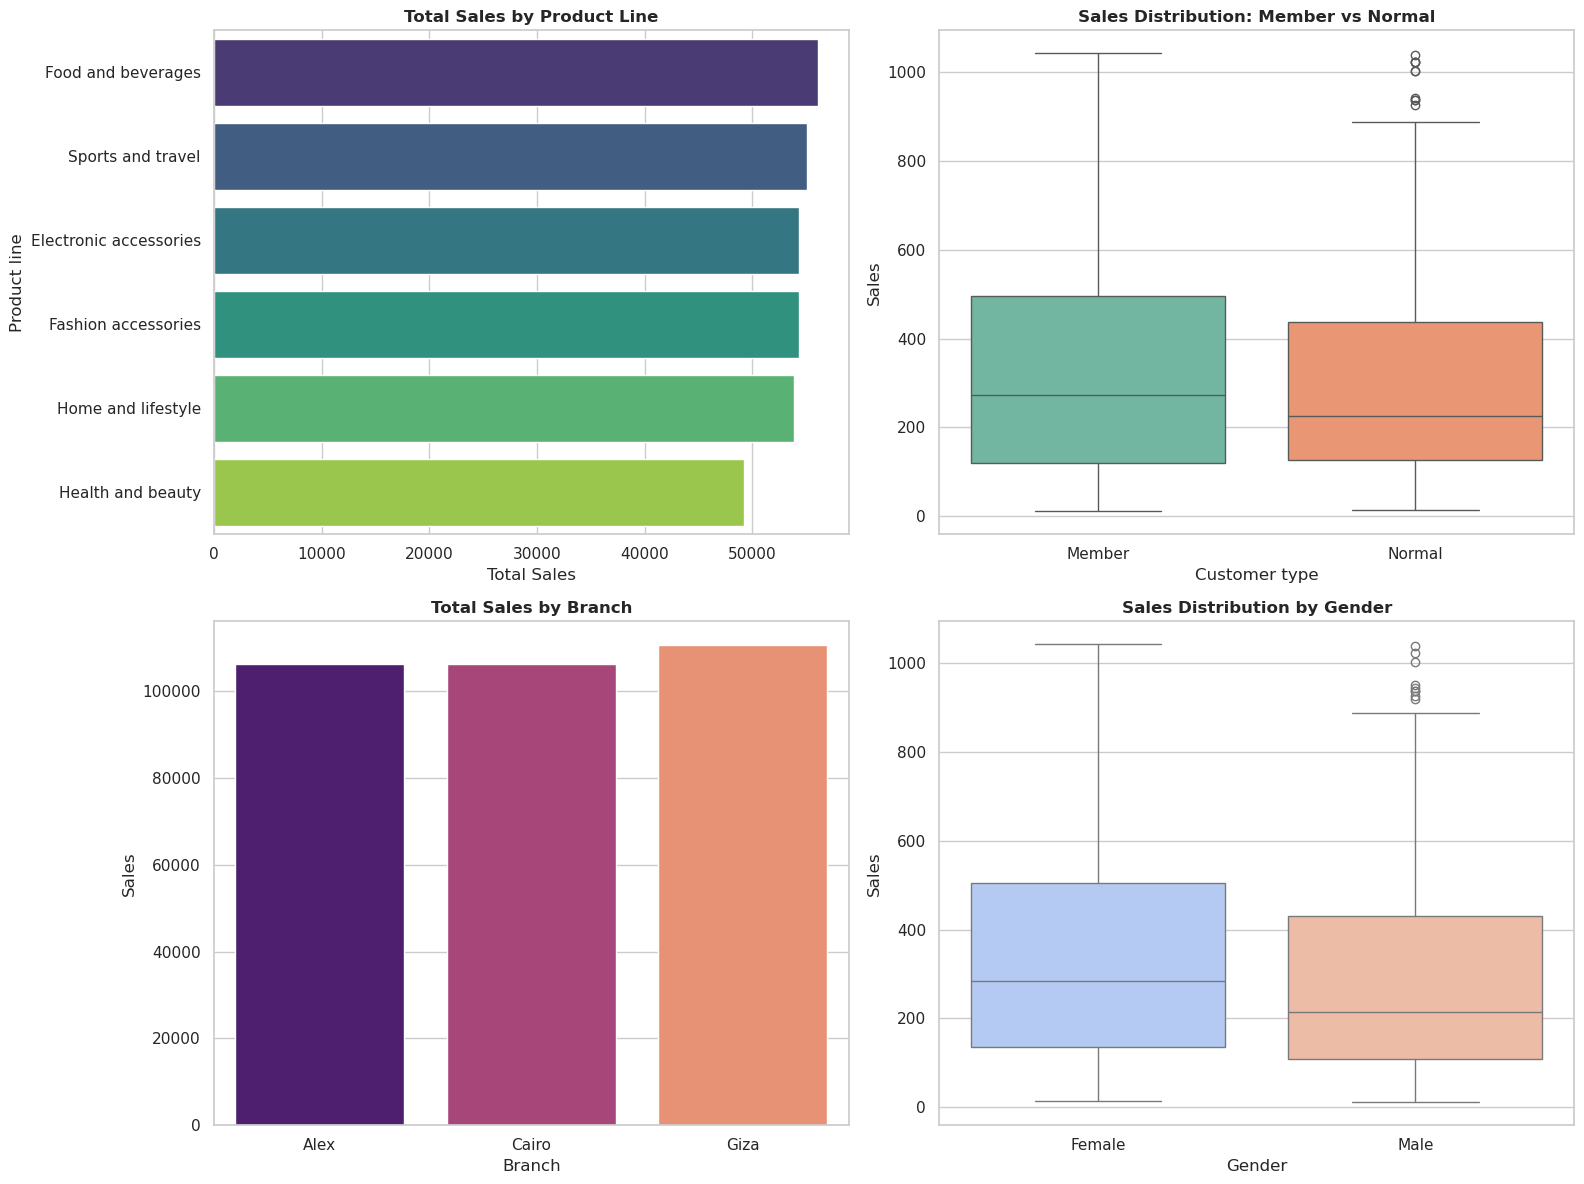

In [2]:
# 1. Exploratory Data Analysis (EDA)
# ════════════════════════════════════════════════════════════
# Let's visualise the data to identify patterns affecting total sales across different categories.

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# Sales by Product Line
plt.subplot(2, 2, 1)
sales_by_product = df.groupby('Product line')[target_col].sum().sort_values(ascending=False)
sns.barplot(y=sales_by_product.index, x=sales_by_product.values, palette='viridis')
plt.title('Total Sales by Product Line', fontweight='bold')
plt.xlabel('Total Sales')

# Sales by Customer Type
plt.subplot(2, 2, 2)
sns.boxplot(x='Customer type', y=target_col, data=df, palette='Set2')
plt.title('Sales Distribution: Member vs Normal', fontweight='bold')

# Sales by Branch
plt.subplot(2, 2, 3)
sales_by_branch = df.groupby('Branch')[target_col].sum()
sns.barplot(x=sales_by_branch.index, y=sales_by_branch.values, palette='magma')
plt.ylabel('Sales')
plt.title('Total Sales by Branch', fontweight='bold')

# Sales by Gender
plt.subplot(2, 2, 4)
sns.boxplot(x='Gender', y=target_col, data=df, palette='coolwarm')
plt.title('Sales Distribution by Gender', fontweight='bold')

plt.tight_layout()
plt.show()

Model Performance Leaderboard
══════════════════════════════════════
Linear Regression:
  R-Squared: -0.0314 | Error (RMSE): $259.04
Decision Tree:
  R-Squared: -1.3108 | Error (RMSE): $387.74
Random Forest:
  R-Squared: -0.1424 | Error (RMSE): $272.63
Gradient Boosting:
  R-Squared: -0.1164 | Error (RMSE): $269.51
K-Nearest Neighbors:
  R-Squared: -0.1177 | Error (RMSE): $269.66
══════════════════════════════════════
🏆 Best Performing Model: Linear Regression


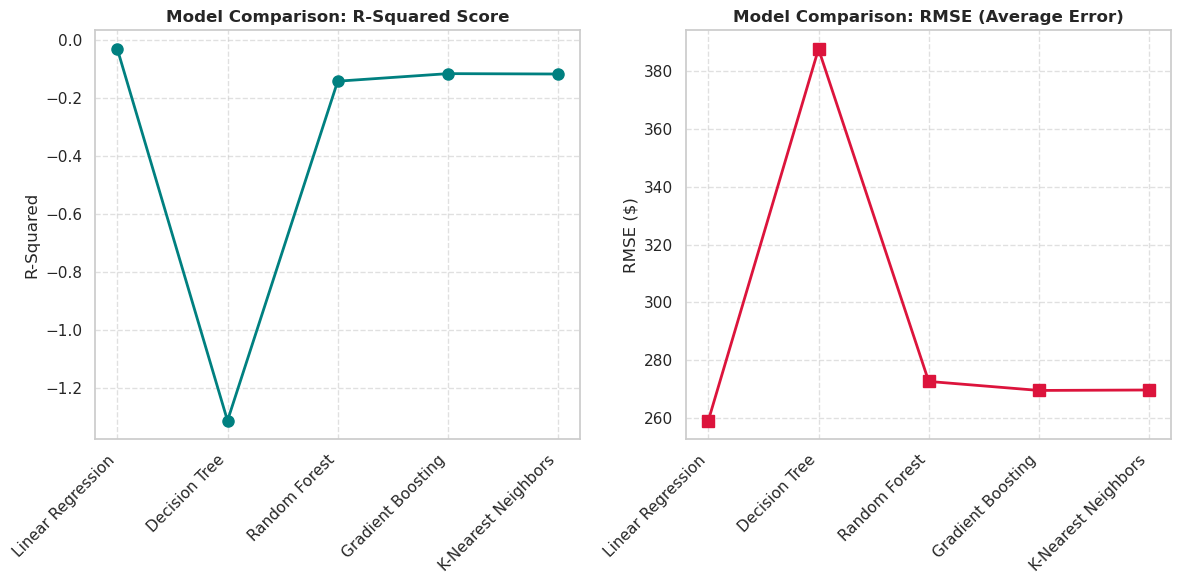

In [3]:
# 2. Data Preprocessing & Modelling
# ════════════════════════════════════════════════════════════
# To build a realistic model that predicts customer spending behaviour, we must drop "leakage" columns (Tax, COGS, Gross Income) because they are mathematically calculated from the target. We also drop Unit Price and Quantity so the model is forced to predict basket value based *only* on the customer's profile and the store location.

# Drop leakage columns and identifiers
columns_to_drop = ['Invoice ID', 'Date', 'Time', 'Tax 5%', 'cogs', 
                   'gross margin percentage', 'gross income', 'Unit price', 'Quantity', target_col]

X = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
y = df[target_col]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5)
}

# Train and Evaluate each model
print(f"Model Performance Leaderboard\n══════════════════════════════════════")
best_model_name = ""
best_score = float('-inf')

# Create empty lists to store data for our plot
model_names = []
r2_scores = []
rmse_scores = []

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Evaluate
    r2 = r2_score(y_test, predictions) 
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    
    # 2. Store the results in our lists
    model_names.append(name)
    r2_scores.append(r2)
    rmse_scores.append(rmse)
    
    print(f"{name}:")
    print(f"  R-Squared: {r2:.4f} | Error (RMSE): ${rmse:.2f}")
    
    # Keep track of the best model based on R-Squared
    if r2 > best_score:
        best_score = r2
        best_model_name = name

print("══════════════════════════════════════")
print(f"🏆 Best Performing Model: {best_model_name}")

# Plot evaluation metric
plt.figure(figsize=(12, 6))

# Subplot 1: R-Squared (Higher is better)
plt.subplot(1, 2, 1)
plt.plot(model_names, r2_scores, marker='o', linestyle='-', color='teal', linewidth=2, markersize=8)
plt.title('Model Comparison: R-Squared Score', fontweight='bold')
plt.ylabel('R-Squared', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate model names so they don't overlap
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: RMSE (Lower is better)
plt.subplot(1, 2, 2)
plt.plot(model_names, rmse_scores, marker='s', linestyle='-', color='crimson', linewidth=2, markersize=8)
plt.title('Model Comparison: RMSE (Average Error)', fontweight='bold')
plt.ylabel('RMSE ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)

# Ensure the plots don't squish together
plt.tight_layout()

# Display the plot
plt.show()

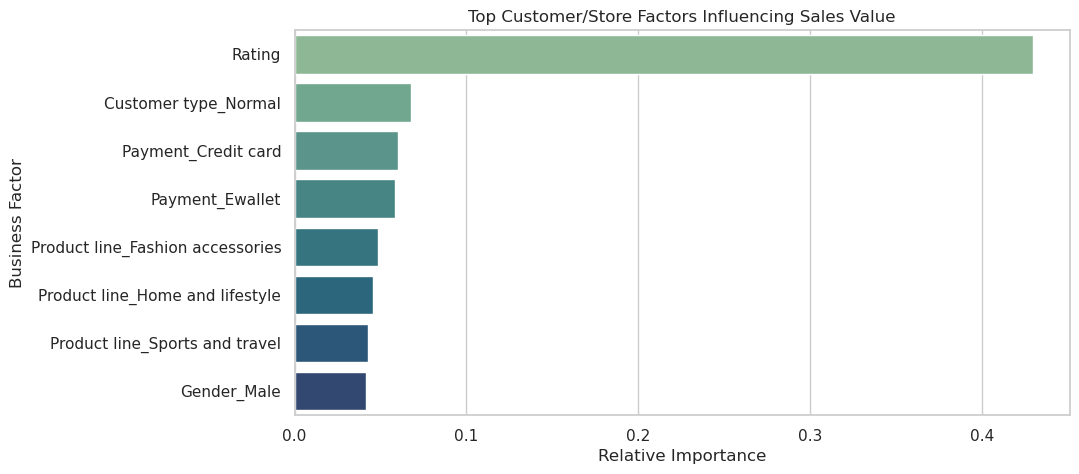

In [4]:
## 3. Feature Importance Analysis
# ════════════════════════════════════════════════════════════
# Using the Random Forest model, we can extract which factors had the strongest (even if slight) influence on the total sales amount.

# Train Random Forest to extract feature importances
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

insights_df = pd.DataFrame({'Factor': X_encoded.columns, 'Importance': importances})
insights_df = insights_df.sort_values(by='Importance', ascending=False).head(8)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Factor', data=insights_df, palette='crest')
plt.title('Top Customer/Store Factors Influencing Sales Value')
plt.xlabel('Relative Importance')
plt.ylabel('Business Factor')
plt.show()